In [6]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np      

from tasks import make_static_sin_task
from encoding_masking import build_masked_input, compute_tdm_params
from Reservoirs.ELM_static import run_elm_static, ELMStaticParams
from readout import split_states_targets, fit_ridge_readout, predict_readout
from metrics import mse, nrmse

# Parameters

In [7]:
L = 2000
N = 50

#reservoir parameters:
p = 1.11 #normalised injection current
eta = 0.08 #input strength 
alpha = 3 #linewidth enhancemenet factor
phi = 0.0 #phase shift
kappa = 10**8

task_seed = 0
mask_seed = 42

g = 1.0
ridge_alpha = 1e-4
split = 0.8

theta = 10**-10
dt = 10**-12

TDM_parameters = compute_tdm_params(N, theta, dt)

print(TDM_parameters)

TDMParams(N=50, theta=1e-10, dt=1e-12, T=5e-09, tau=5.0500000000000006e-09, Nd=5050, tap_stride=100)


# task import

In [8]:
task = make_static_sin_task(L=L, seed=task_seed)
x, y = task.x, task.y


# masked Input V_ln

In [9]:
x_norm, mask, V = build_masked_input(x, N=N, rng=mask_seed) # V is really the output only care about here.

# Masked input Vln -> V(steps) ie convert to a 1d array as (function of steps)

In [10]:
#tap_stride = 5
#Nd = N * tap_stride
#Vs = empty array size LxNxtap_stride
'''
Pseudocode

for l in 0 to L
    for n in 0 to N
        for steps in n*tap_stride to (n+1)*tap_stride

            Vs(steps + l*Nd) = V(l,n)
'''

def expand_virtual_nodes(V, tap_stride, Nd):

    L, N = V.shape
    #Nd = N * tap_stride

    Vs = np.zeros(L * Nd)

    for l in range(L):
        for n in range(N):
            for step in range(n * tap_stride, (n + 1) * tap_stride):
                Vs[step + l * Nd] = V[l, n]

    return Vs


# DDE + RK4 functions 

In [11]:
def ODEs(E, n, E_delay, v_slot, alpha, kappa, phi, p, eta):
  
  
    I = abs(E)**2  

    dEdt = (1.0 + 1j*alpha) * E - I * E + kappa * E_delay * np.exp(1j*phi)

    dndt = p + eta * v_slot - (1.0 + I) * n

    return dEdt, dndt


In [12]:
def rk4_step(E, n, E_delay, v_slot, dt, alpha, kappa, phi, p, eta):
    
   # One RK4 step. v should be v over tap_stride duration. 
 
    # k1
    k1_E, k1_n = ODEs(E, n, E_delay, v_slot, alpha, kappa, phi, p, eta)

    # k2
    E2 = E + 0.5 * dt * k1_E
    n2 = n + 0.5 * dt * k1_n
    k2_E, k2_n = ODEs(E2, n2, E_delay, v_slot, alpha, kappa, phi, p, eta)

    # k3
    E3 = E + 0.5 * dt * k2_E
    n3 = n + 0.5 * dt * k2_n
    k3_E, k3_n = ODEs(E3, n3, E_delay, v_slot, alpha, kappa, phi, p, eta)

    # k4
    E4 = E + dt * k3_E
    n4 = n + dt * k3_n
    k4_E, k4_n = ODEs(E4, n4, E_delay, v_slot, alpha, kappa, phi, p, eta)


    E_next = E + (dt/6.0) * (k1_E + 2*k2_E + 2*k3_E + k4_E)
    n_next = n + (dt/6.0) * (k1_n + 2*k2_n + 2*k3_n + k4_n)

    return E_next, n_next


# Running ODE

In [13]:

def simulate_lk(Vs, dt, Nd_delay, *, alpha, kappa, phi, p, eta, E0=1e-3+0j, n0=0.0):
    Vs = np.asarray(Vs, dtype=float)
    T_steps = Vs.size

    E_hist = np.zeros(T_steps, dtype=np.complex128)
    n_hist = np.zeros(T_steps, dtype=float)

    # delay buffer holds E(t - tau)
    delay_buf = np.full(Nd_delay, E0, dtype=np.complex128)
    di = 0 #Index pointer for delay buffer

    E, n = E0, n0
    for t in range(T_steps):
        v_slot = float(Vs[t])
        E_delay = delay_buf[di]

        E, n = rk4_step(E, n, E_delay, v_slot, dt, alpha, kappa, phi, p, eta)

        E_hist[t] = E
        n_hist[t] = n

        delay_buf[di] = E
        di = (di + 1) % Nd_delay

    return E_hist, n_hist


def extract_R_from_E(E_hist, L, N, tap_stride, Nd_loop):
    R = np.zeros((L, N), dtype=float)
    for l in range(L):
        base = l * Nd_loop
        for n in range(N):
            t_idx = base + (n + 1) * tap_stride - 1  # end of slot
            R[l, n] = np.abs(E_hist[t_idx])**2
    return R



In [14]:
tap_stride = TDM_parameters.tap_stride  
Nd_loop = TDM_parameters.Nd          
tau = TDM_parameters.tau

Nd_delay = int(round(tau / dt))

Vs = expand_virtual_nodes(V, tap_stride=tap_stride, Nd=Nd_loop)  
E_hist, n_hist = simulate_lk(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta, E0=1e-3+0j, n0=0.0)
R = extract_R_from_E(E_hist, L=L, N=N, tap_stride=tap_stride, Nd_loop=Nd_loop)
print("R shape:", R.shape)  # should be (L, N)



R shape: (2000, 50)


MSE: 0.49549177398232497
NRMSE: 1.000770144920322


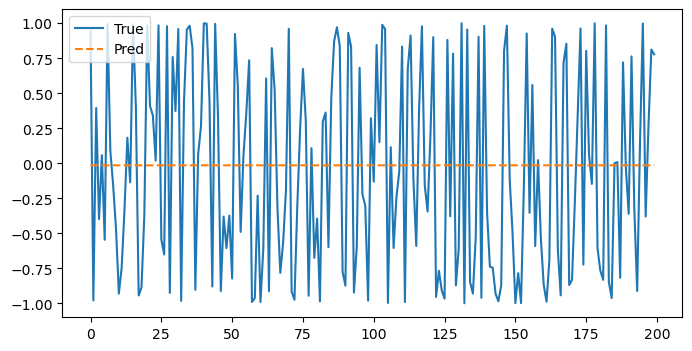

In [15]:
s = split_states_targets(R, y, split=split)
model = fit_ridge_readout(s.R_train, s.y_train, alpha=ridge_alpha, fit_intercept=False)
y_pred = predict_readout(model, s.R_test)

print("MSE:", mse(s.y_test, y_pred))
print("NRMSE:", nrmse(s.y_test, y_pred))

plt.figure(figsize=(8,4))
plt.plot(s.y_test[:200], label="True")
plt.plot(y_pred[:200], "--", label="Pred")
plt.legend()
plt.show()